Module importing

In [32]:
import sys
import torch
import random
import numpy as np
import torch.nn as nn
import torch.optim as optim
import scipy.signal as signal
import matplotlib.pyplot as plt
from torch.utils.data import Dataset,DataLoader,TensorDataset,random_split,SubsetRandomSampler, ConcatDataset

sys.path.append('D:/ppg_project/code/model_build/my_tool/model')
from unet_lstm_AI import unet_lstm
sys.path.append(r'D:/ppg_project/code/model_build/my_tool/tool')
from model_builder import k_fold_training
from performance import performance
sys.path.append(r'D:/ppg_project/code/model_build/my_tool/tool/data_load')
from ppg_labeled_load import PPGDataset

Data prepairing

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Admin\AppData\Local\Temp\ipykernel_3700\2803335453.py:2: SyntaxWarning: invalid escape sequence '\p'
  dataset = PPGDataset('D:\ppg_project\Data\data_train',label_list = {"Case":["PAC","PVC","PAC-nhip-doi","PAC-cap-doi","PVC-nhip-doi","PVC-cap-doi"],"Group": True})


254
torch.Size([1, 800])


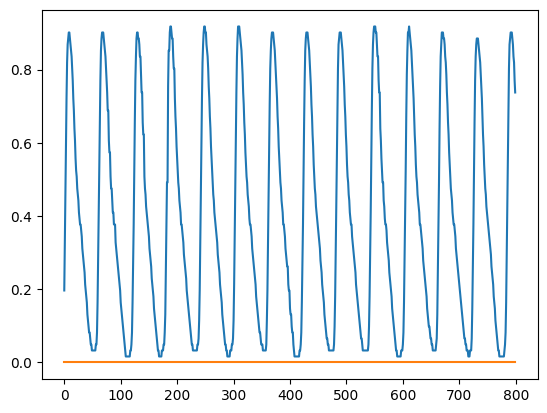

In [33]:
#Import_data
dataset = PPGDataset('D:\ppg_project\Data\data_train',label_list = {"Case":["PAC","PVC","PAC-nhip-doi","PAC-cap-doi","PVC-nhip-doi","PVC-cap-doi"],"Group": True})
print(dataset.count)

print(dataset[111][0].shape)
for i in [22]:
    plt.plot(dataset[i][0].numpy().flatten())
    plt.plot(dataset[i][1].numpy().flatten())

# plt.plot(dataset[0][1].numpy())
    plt.show()

Training

In [38]:
# trainning test cho code AI
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

para = {
    "Serie length":         800,
    "Input size":           1,
    "Hidden size":          512,
    "Number layers":        2,
    "Encoder structure":    [1,64,128,256,512], 
    "Decoder structure":    [512,256,128,64,1],
    "Kernel size":          [3,3,3,3,3,3,3,3,3],
    "Kernel encoder":       [8,8,8,8],
    "Kernel decoder":       [4,4,4,4],
    "Stride":               [2,2,2,2],
    "Activate function":    nn.ReLU(),  # ✅ Đổi từ Tanh → ReLU
    "Output activation":    None  # ✅ THÊM: Không giới hạn output range
}

model = unet_lstm(para).to(device)  # ✅ THÊM .to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)  # ✅ THÊM weight_decay

# ✅ MSE thay vì L1 (tốt hơn cho signal reconstruction)
criterion = nn.L1Loss()

builder = k_fold_training(dataset, 1, criterion=criterion)
builder.training(model, device, optimizer, num_epochs=1500, batch=64, visualize=1)

True
Iteration: 1/1500. loss_train: 0.2420601099729538. loss_val: 0
Iteration: 2/1500. loss_train: 0.14936070144176483. loss_val: 0
Iteration: 3/1500. loss_train: 0.11218896508216858. loss_val: 0
Iteration: 4/1500. loss_train: 0.08709201216697693. loss_val: 0
Iteration: 5/1500. loss_train: 0.07213392853736877. loss_val: 0
Iteration: 6/1500. loss_train: 0.06300178915262222. loss_val: 0
Iteration: 7/1500. loss_train: 0.05535341426730156. loss_val: 0
Iteration: 8/1500. loss_train: 0.04934116452932358. loss_val: 0
Iteration: 9/1500. loss_train: 0.04723207280039787. loss_val: 0
Iteration: 10/1500. loss_train: 0.04354187473654747. loss_val: 0
Iteration: 11/1500. loss_train: 0.04468410834670067. loss_val: 0
Iteration: 12/1500. loss_train: 0.04161025583744049. loss_val: 0
Iteration: 13/1500. loss_train: 0.04045376181602478. loss_val: 0
Iteration: 14/1500. loss_train: 0.03582095354795456. loss_val: 0
Iteration: 15/1500. loss_train: 0.03384901210665703. loss_val: 0
Iteration: 16/1500. loss_train

In [29]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

para = {"Serie length":         800,
            "Input size":           1,
            "Hidden size":          512,
            "Number layers":        2,
            "Encoder structure":    [1,64,128,256,512], 
            "Decoder structure":    [512,256,128,64,100],
            "Kernel size":          [3,3,3,3,3,3,3,3,3],
            "Kernel encoder":       [8,8,8,8],
            "Kernel decoder":       [4,4,4,4],
            "Stride":               [2,2,2,2],
            "Activate function":    nn.Tanh()
    }

model = unet_lstm(para)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
# builder = k_fold_training(train_data, 1, criterion = nn.L1Loss())
builder = k_fold_training(dataset,1,criterion = nn.L1Loss())
builder.training(model,device,optimizer,num_epochs=1500,batch=64,visualize=1)

True
Iteration: 1/1500. loss_train: 0.07345256209373474. loss_val: 0
Iteration: 2/1500. loss_train: 0.06654655933380127. loss_val: 0
Iteration: 3/1500. loss_train: 0.06173869967460632. loss_val: 0
Iteration: 4/1500. loss_train: 0.057820066809654236. loss_val: 0
Iteration: 5/1500. loss_train: 0.054763343185186386. loss_val: 0
Iteration: 6/1500. loss_train: 0.05214526876807213. loss_val: 0
Iteration: 7/1500. loss_train: 0.050615452229976654. loss_val: 0
Iteration: 8/1500. loss_train: 0.04987214133143425. loss_val: 0
Iteration: 9/1500. loss_train: 0.04930943250656128. loss_val: 0
Iteration: 10/1500. loss_train: 0.04895259812474251. loss_val: 0
Iteration: 11/1500. loss_train: 0.048423271626234055. loss_val: 0
Iteration: 12/1500. loss_train: 0.04843124747276306. loss_val: 0
Iteration: 13/1500. loss_train: 0.048222802579402924. loss_val: 0
Iteration: 14/1500. loss_train: 0.04815853759646416. loss_val: 0
Iteration: 15/1500. loss_train: 0.048138365149497986. loss_val: 0
Iteration: 16/1500. los

Performance

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Admin\AppData\Local\Temp\ipykernel_3700\2692554754.py:2: SyntaxWarning: invalid escape sequence '\p'
  test_data = PPGDataset('D:\ppg_project\Data\data_test',label_list = "AR")


Max loss:  1.0
Mean loss:  0.27155194
Min loss:  0.0
Number of test:  84


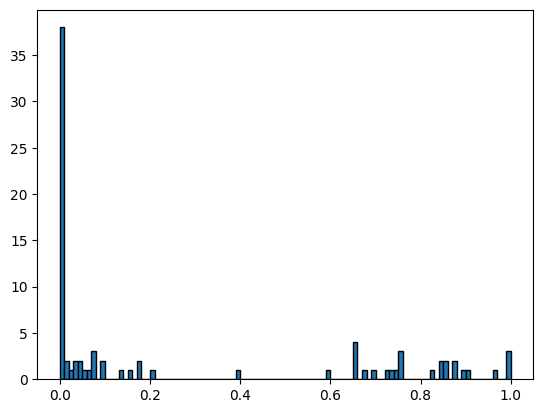

0.1575


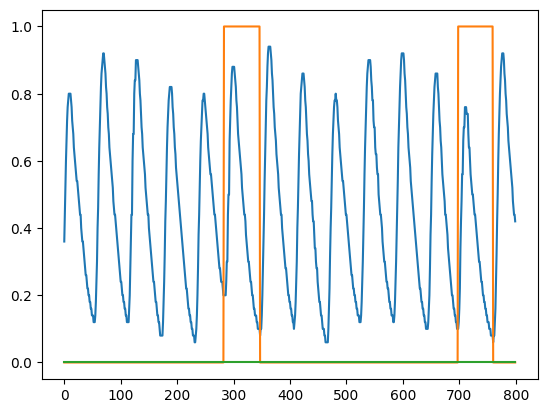

0.75325704


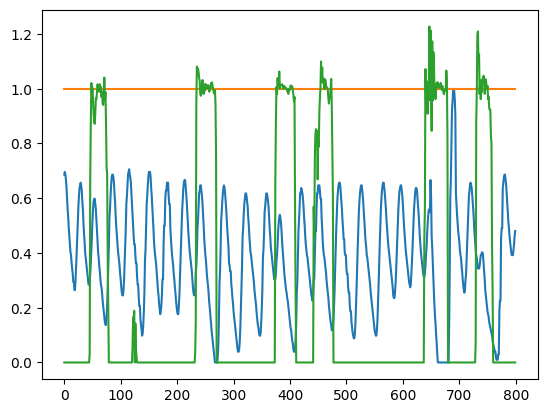

0.7248405


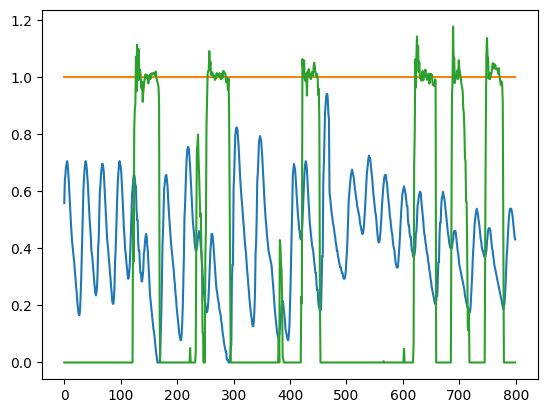

0.0


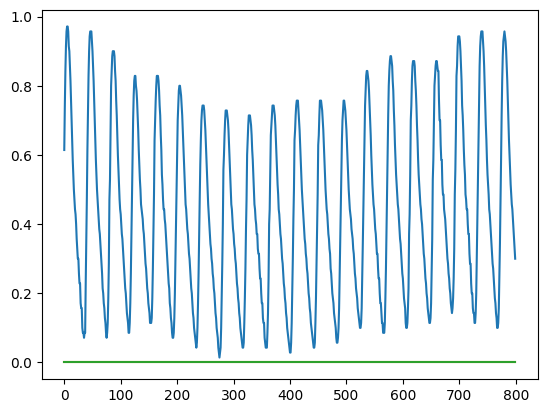

0.0


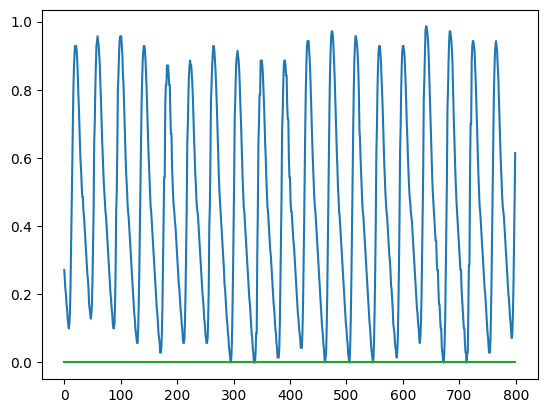

0.0


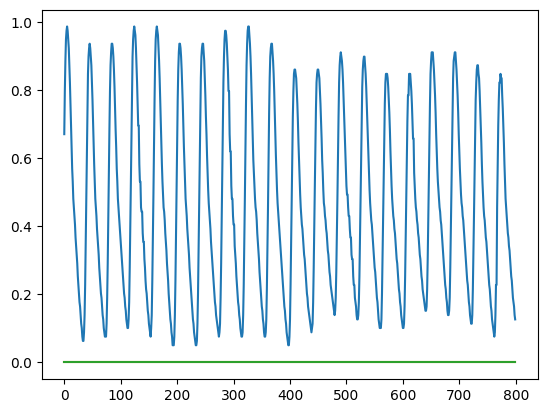

0.0


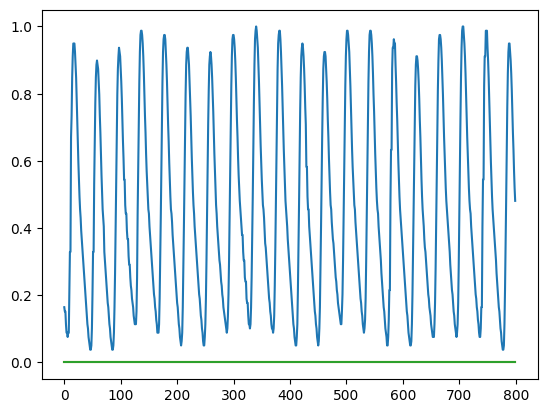

0.0


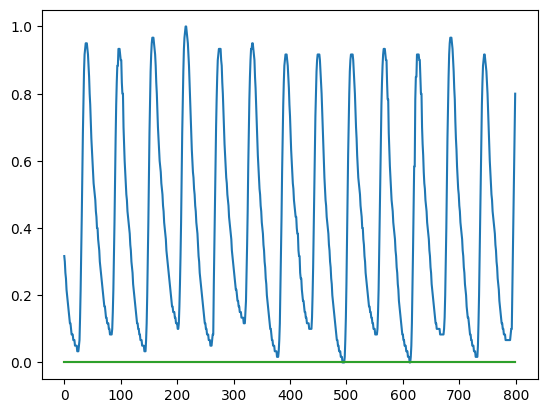

0.0


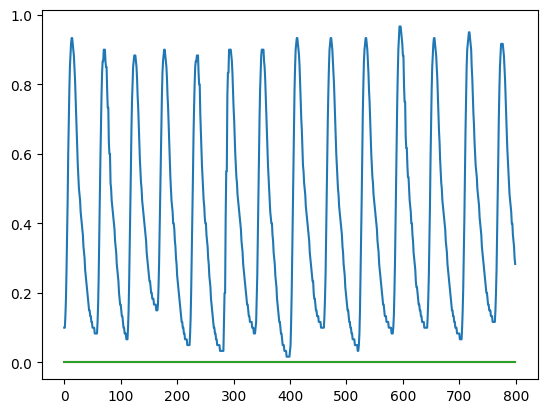

0.0


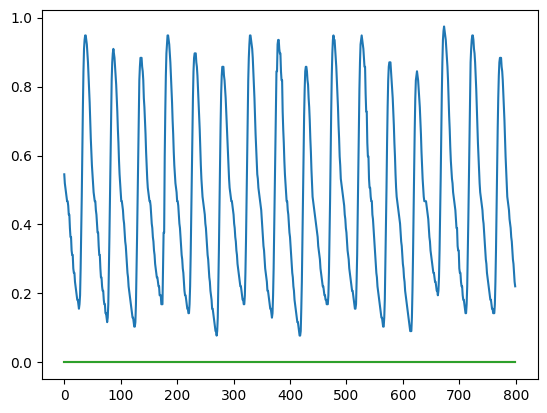

0.0


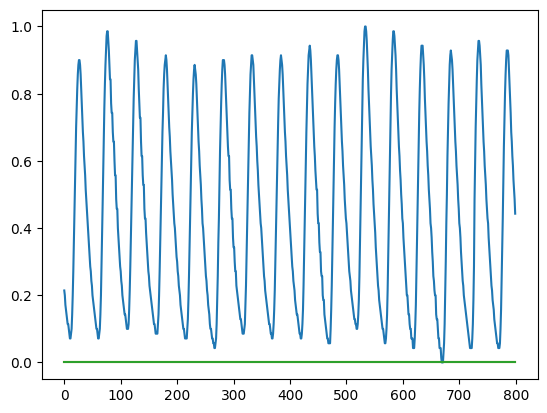

0.0


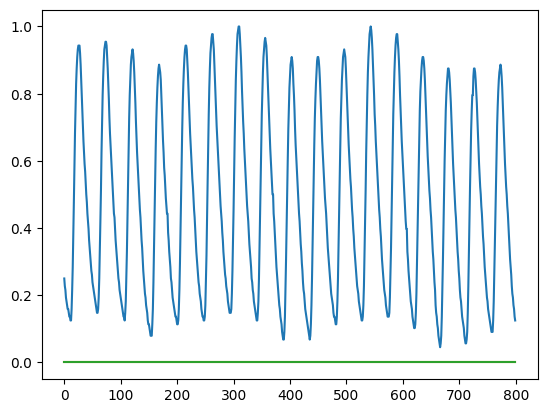

0.016419565


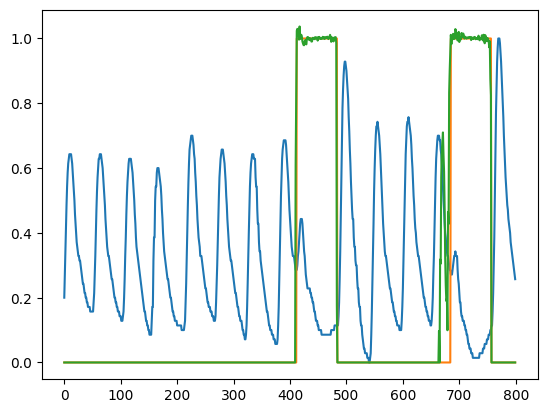

0.0


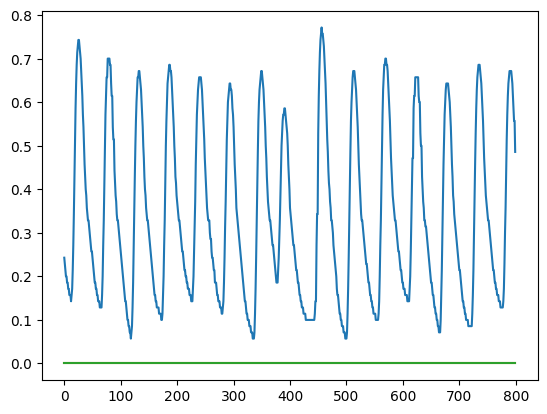

0.07603456


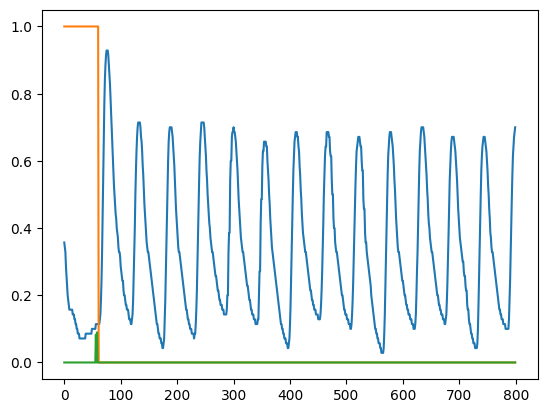

0.0


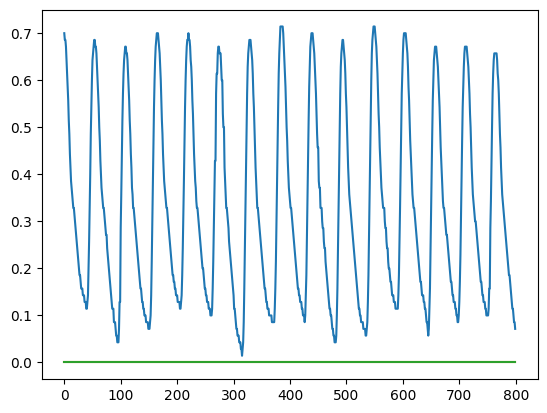

0.84984505


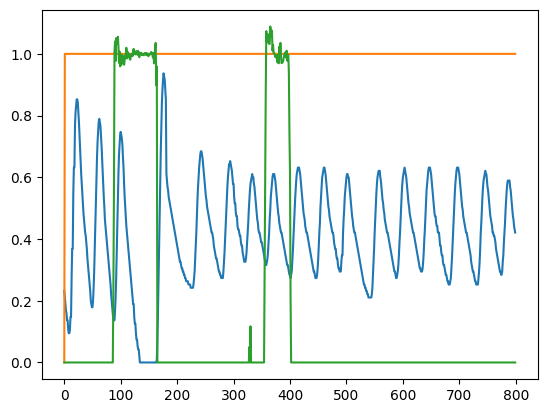

0.8512086


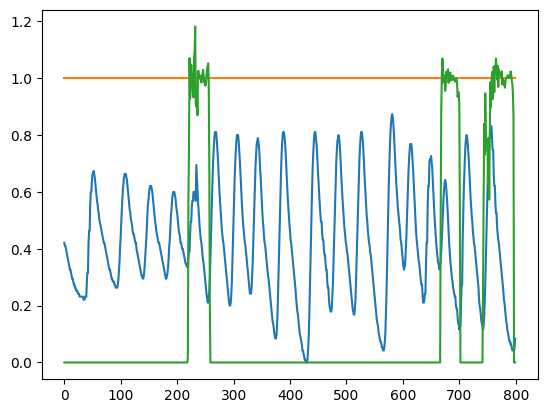

0.7561619


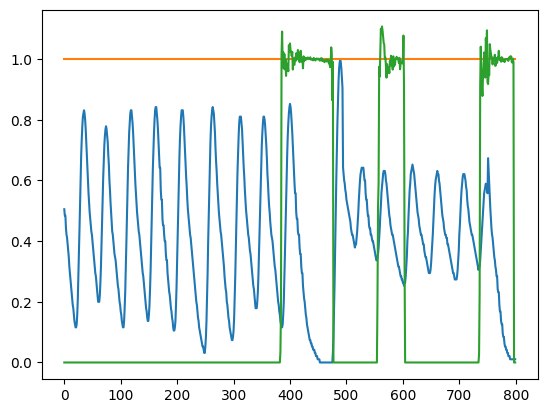

0.6579541


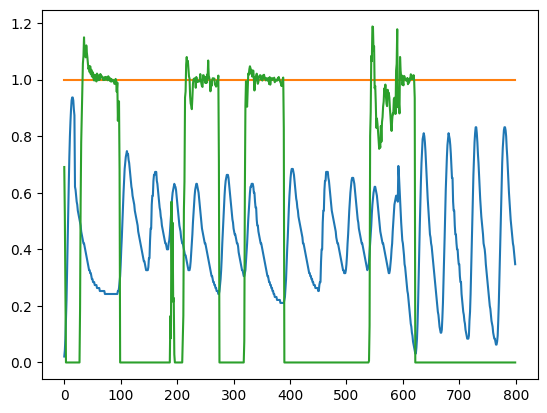

0.896242


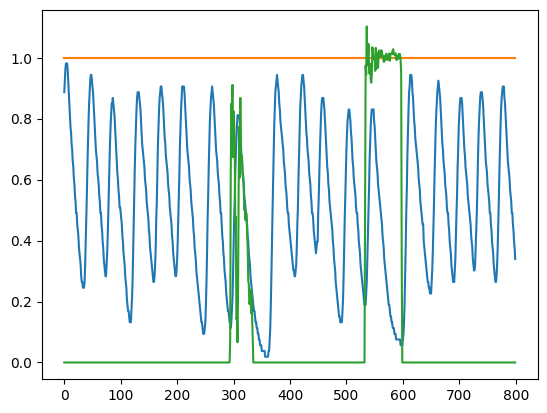

0.0


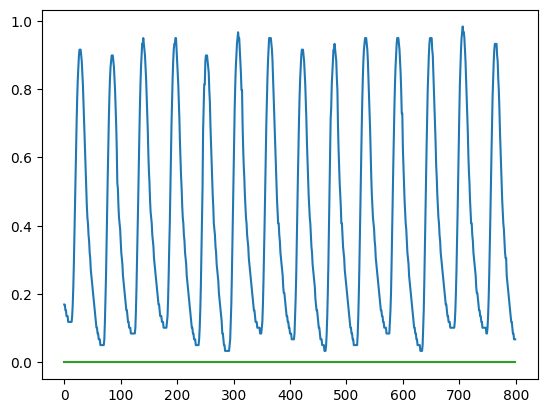

0.0


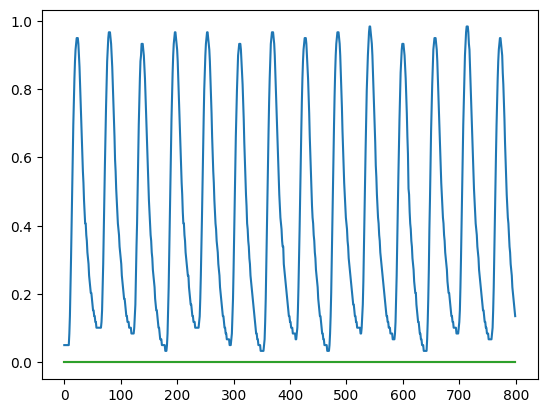

0.0


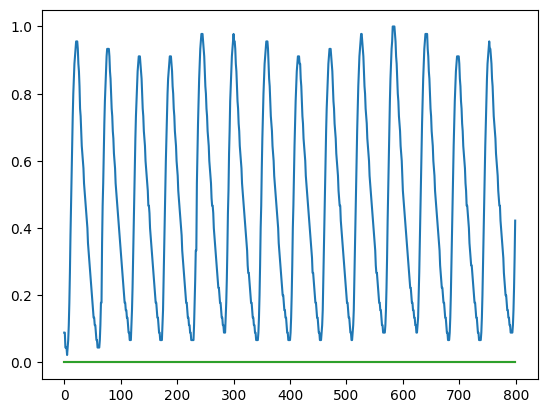

0.0


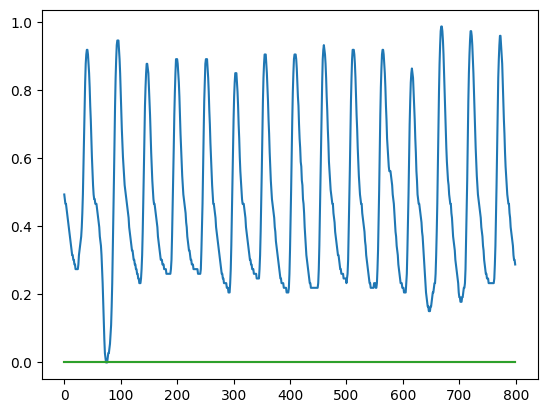

0.0


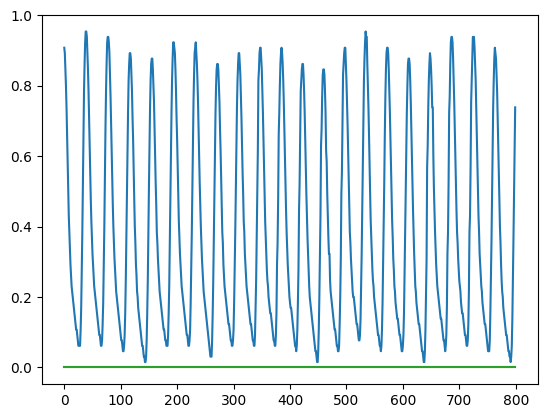

0.9665021


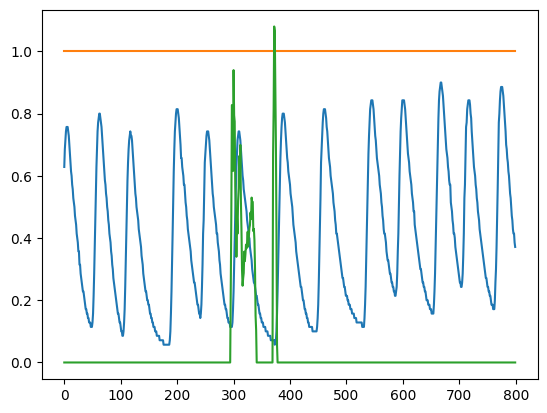

0.0


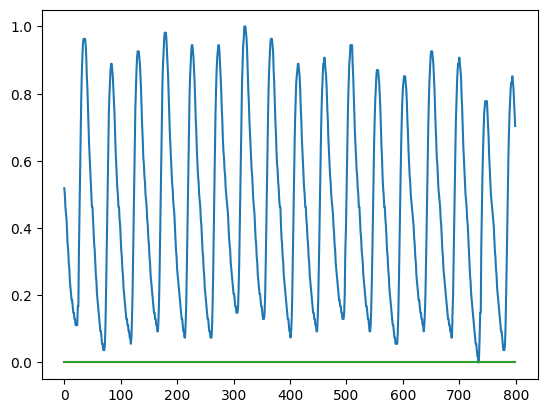

0.0


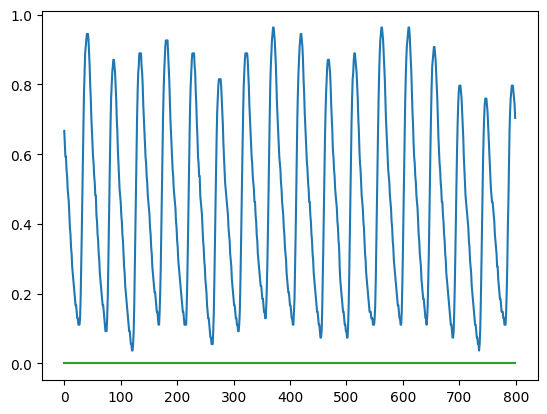

0.6596707


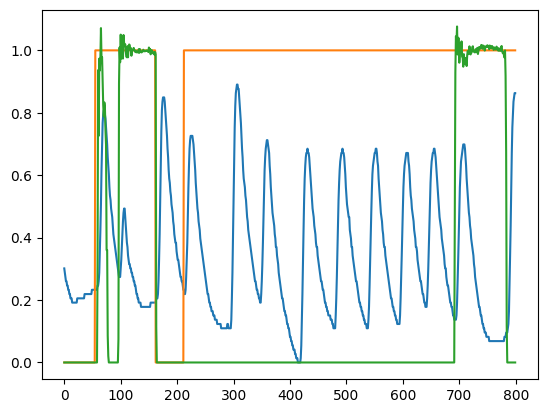

0.0


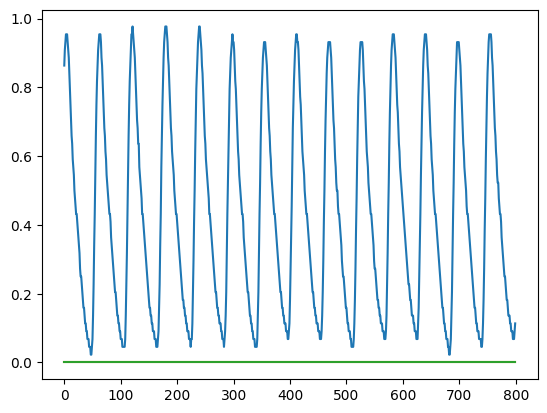

0.0


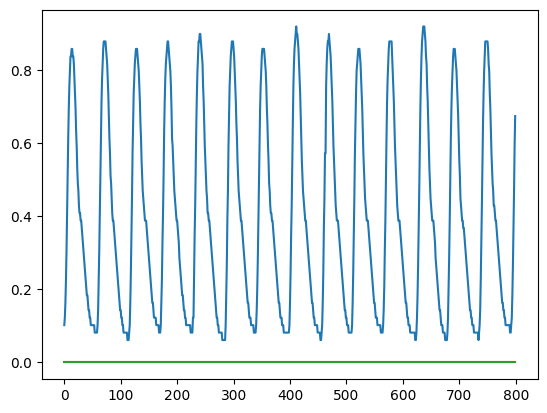

0.0


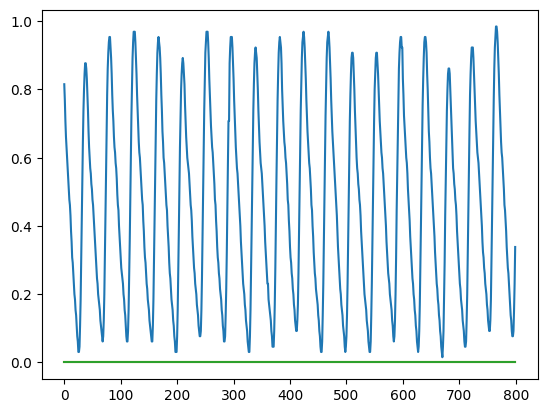

0.0


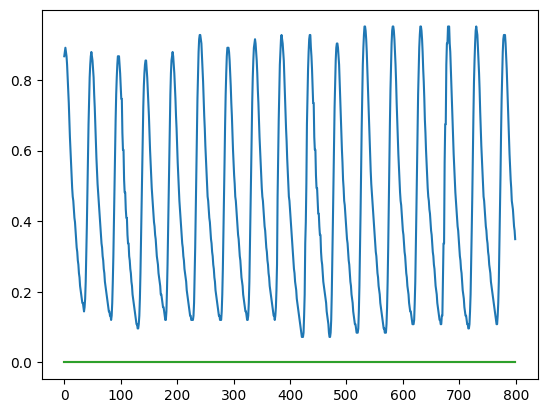

0.0


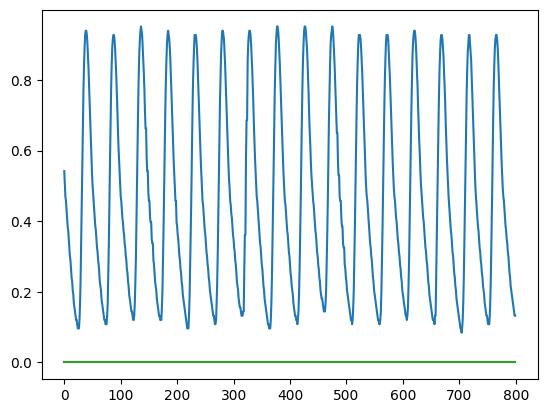

0.0


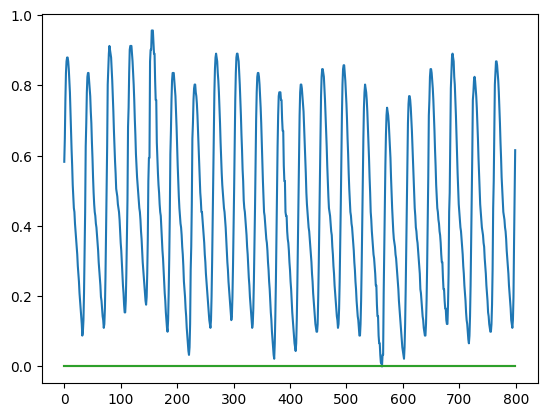

4.993471e-06


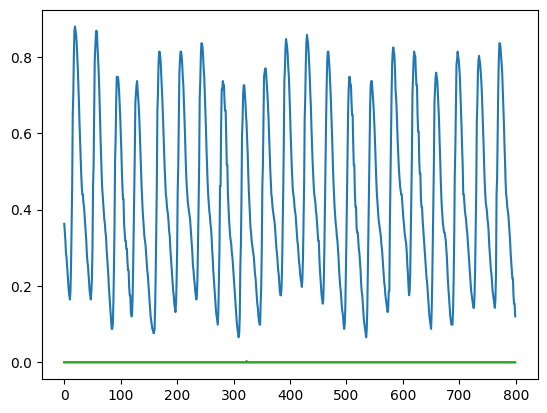

0.0


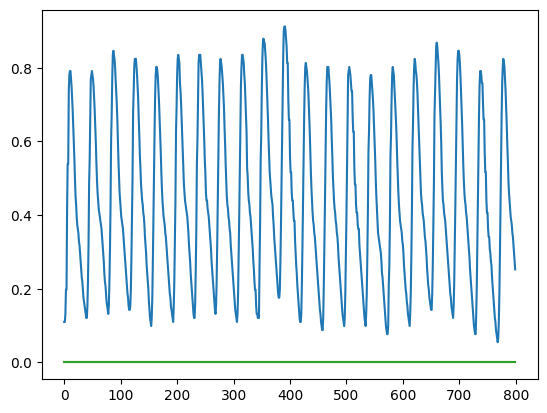

0.0


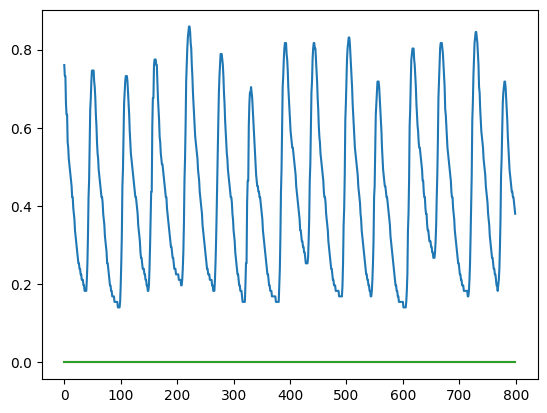

0.65810144


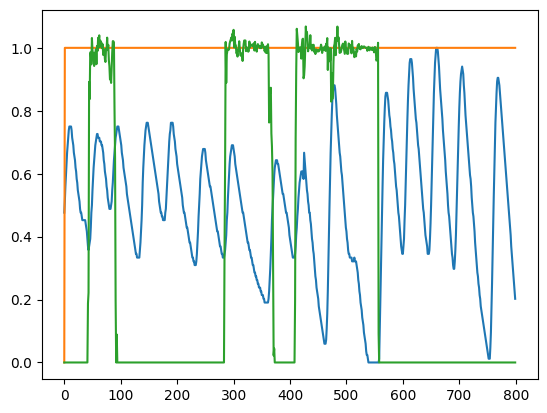

0.0


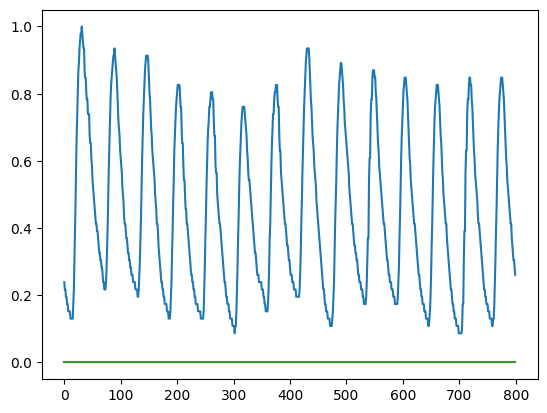

0.7509191


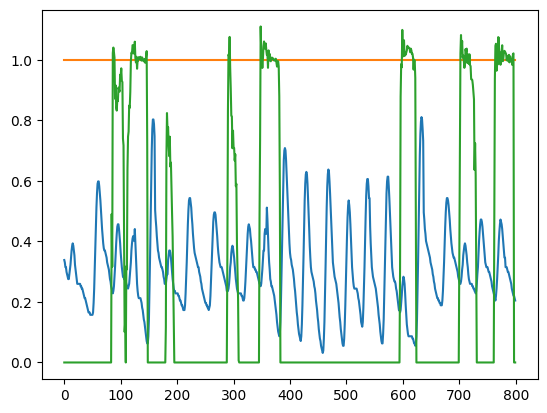

0.9049324


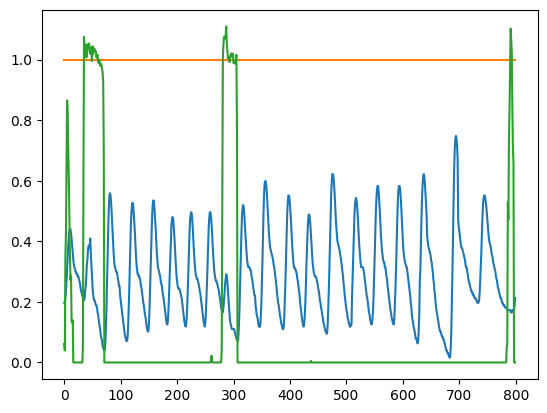

0.0


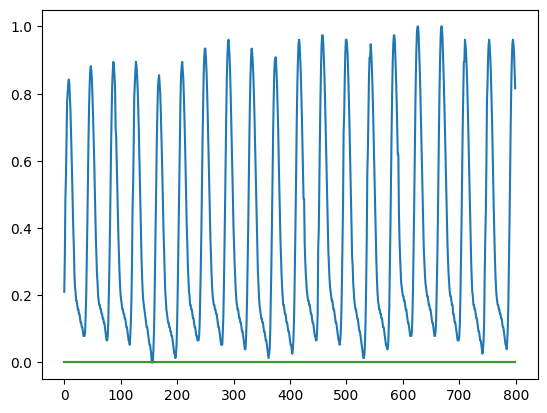

0.04239355


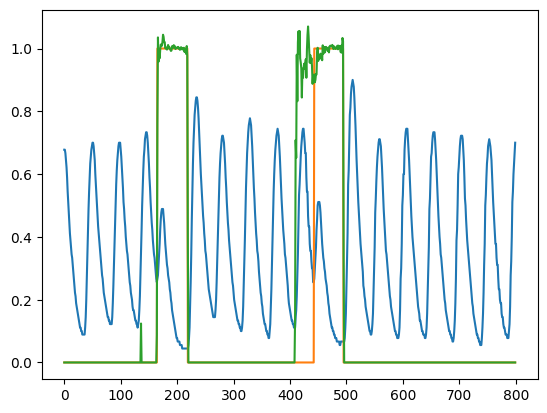

0.046012867


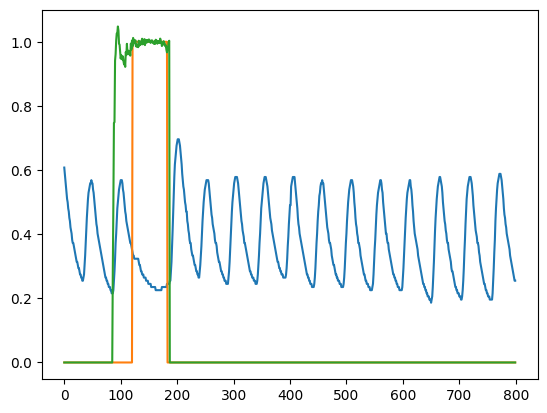

0.06022786


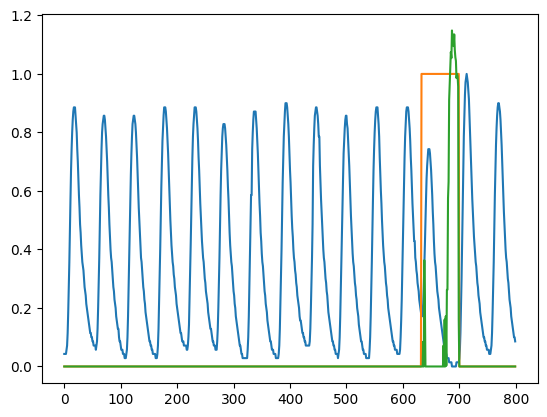

0.65416676


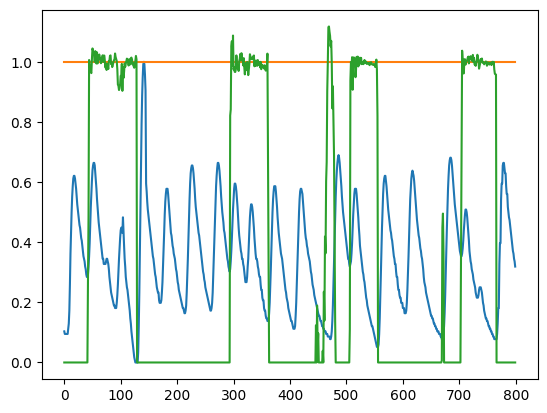

0.69224286


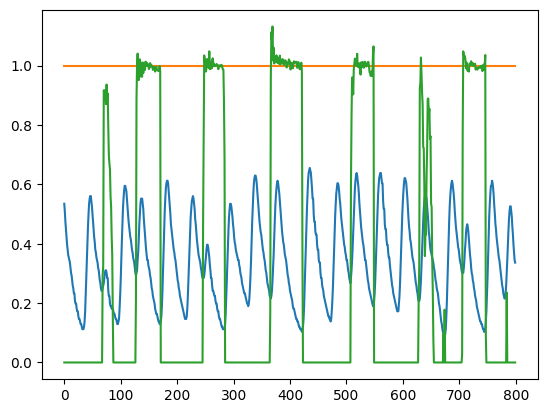

0.09033145


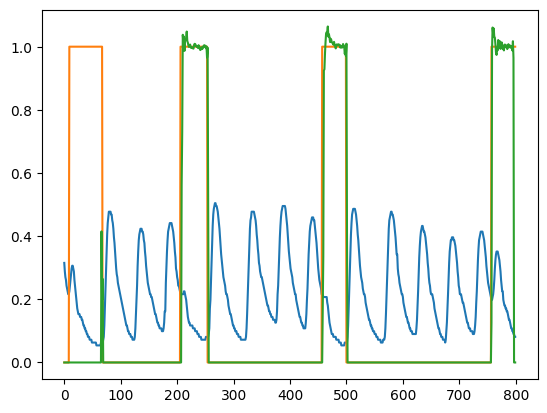

0.035430226


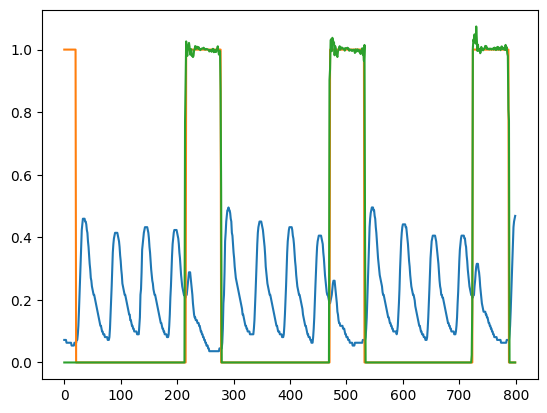

0.0076306504


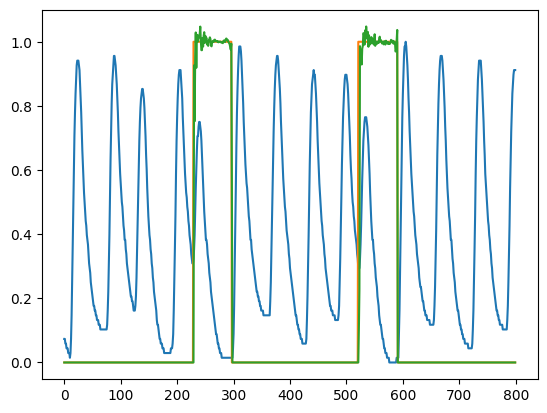

0.0


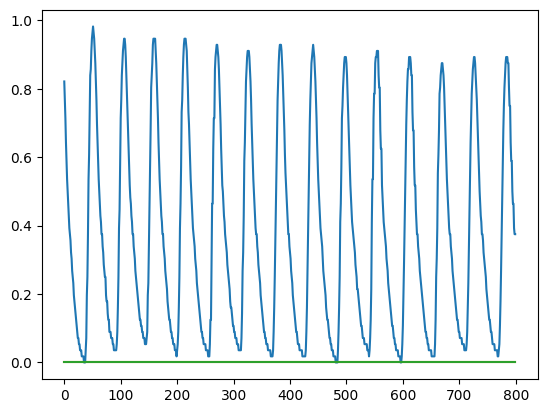

0.0


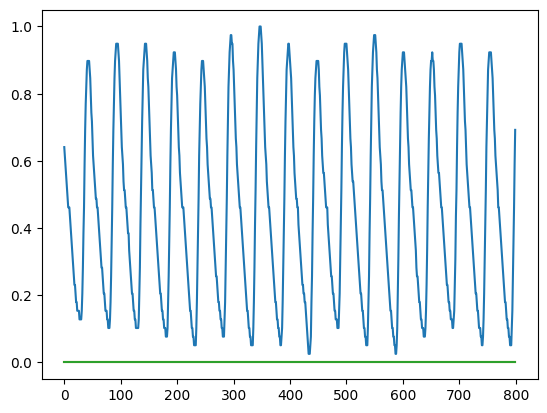

0.0


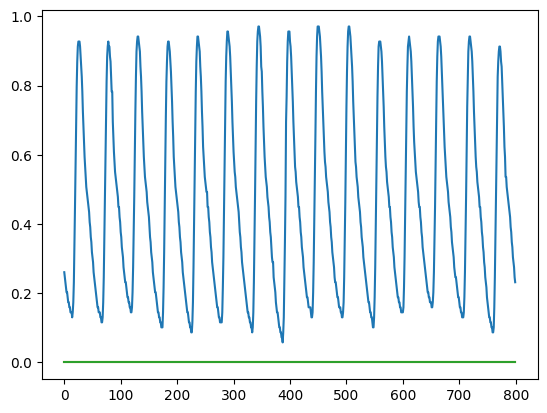

0.6758615


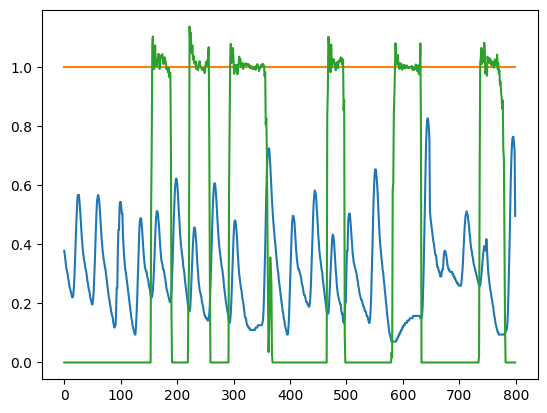

0.59893334


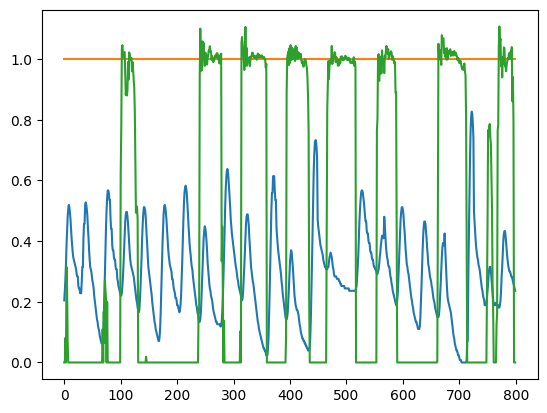

0.07375


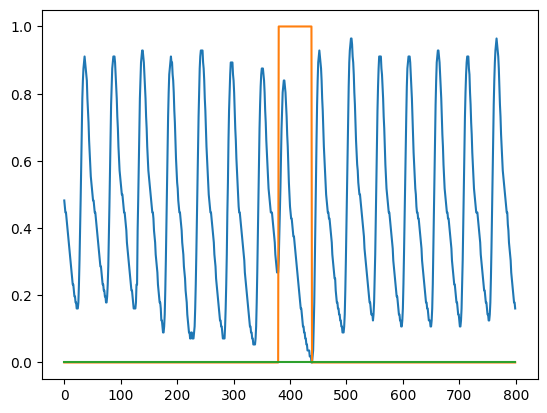

1.0


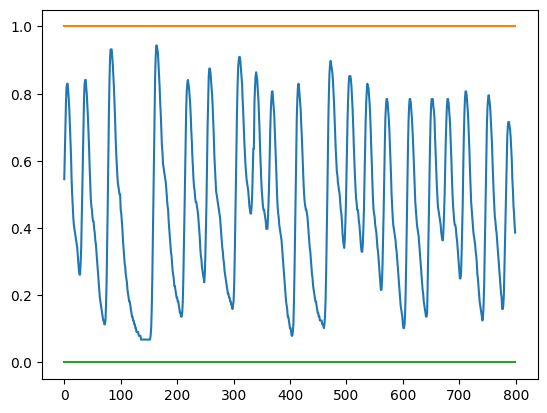

0.8419911


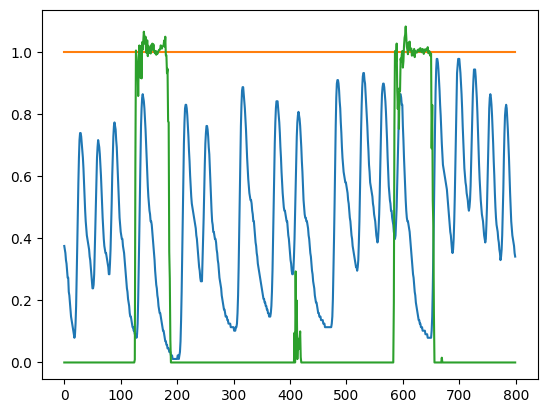

1.0


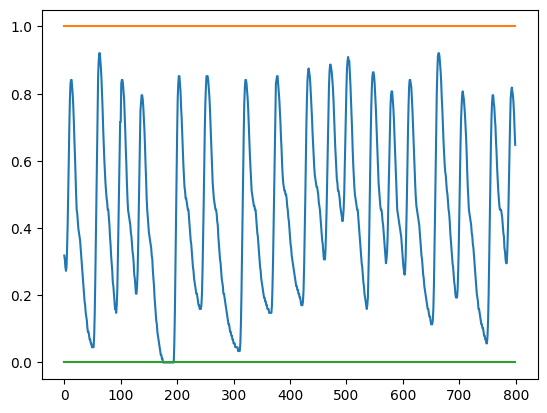

0.20825668


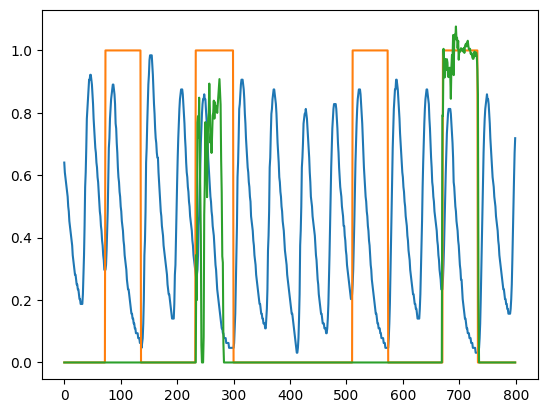

0.39607817


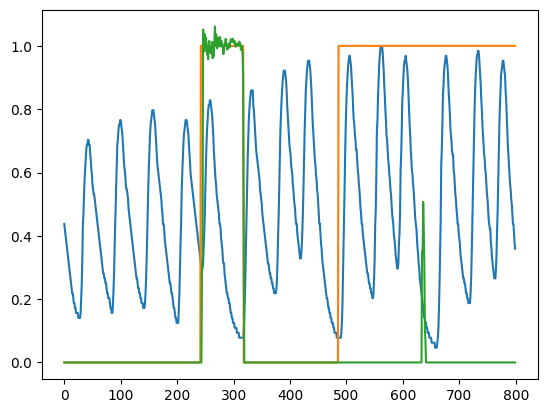

0.035159323


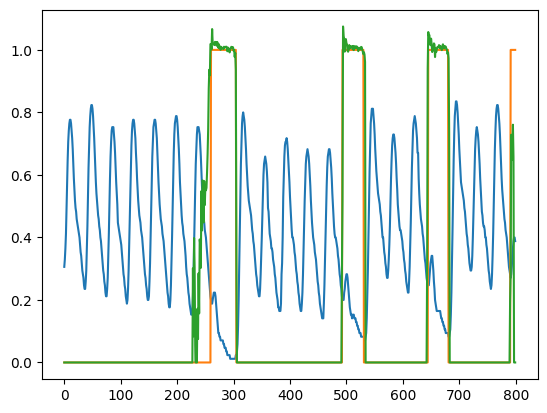

0.13077937


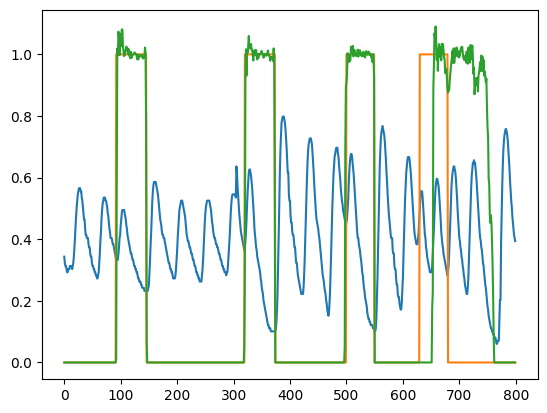

0.0


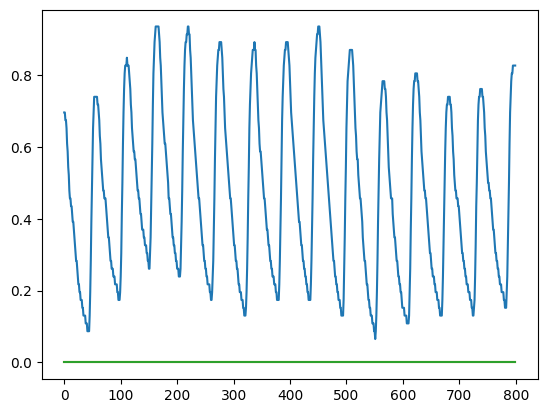

0.7364802


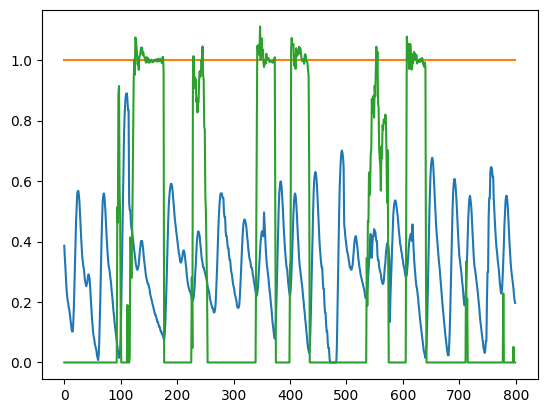

0.17732391


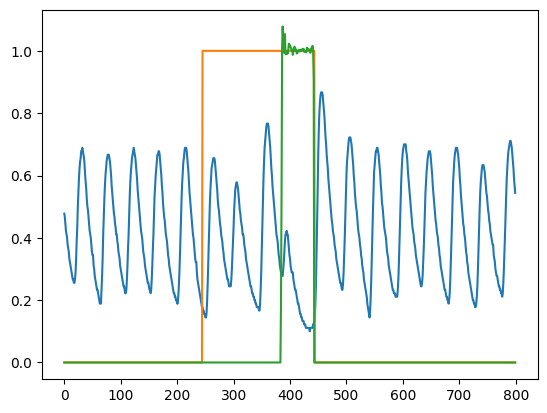

0.1738404


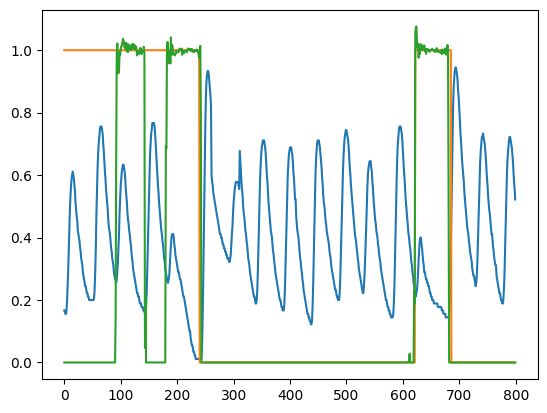

0.05497304


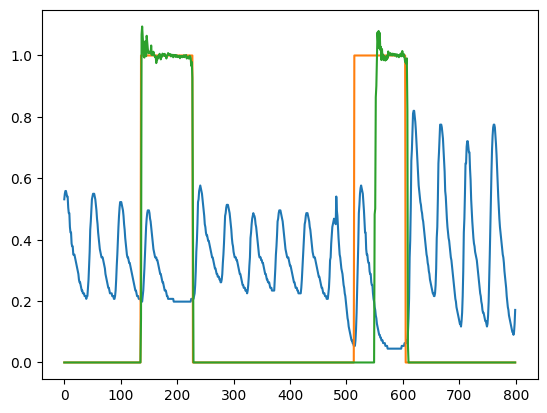

0.011098261


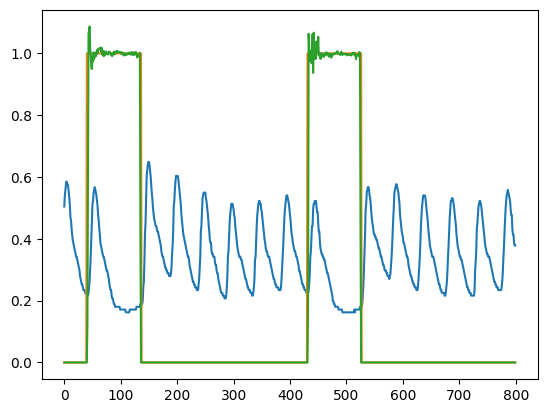

0.009686872


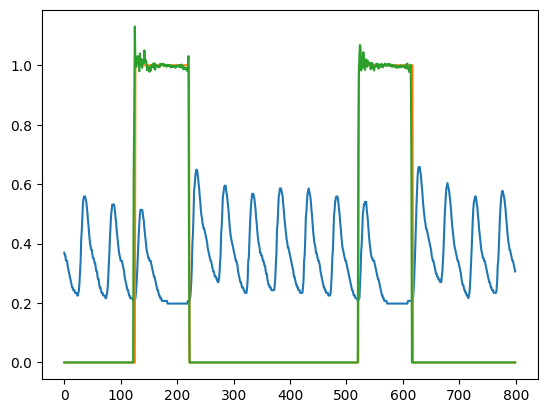

0.0045744376


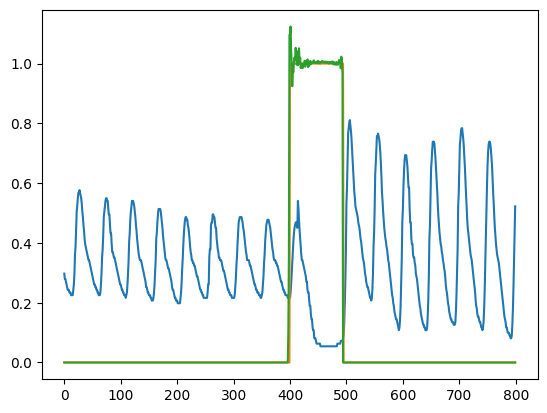

0.005419942


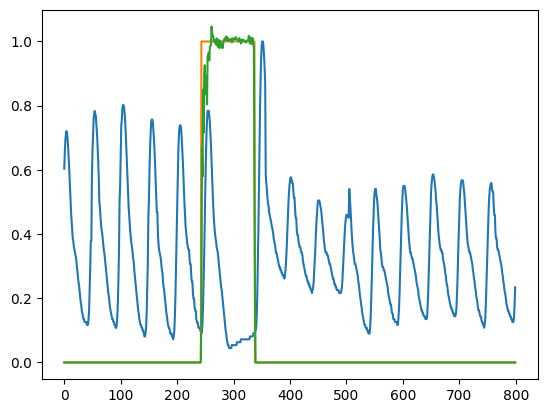

0.8221012


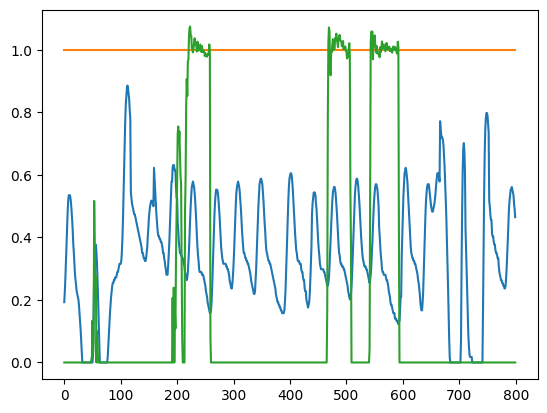

0.85299027


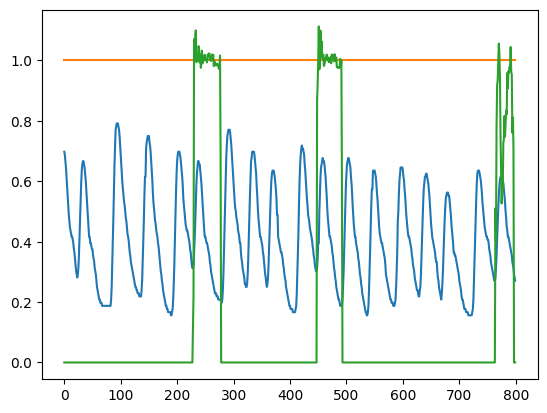

0.8770759


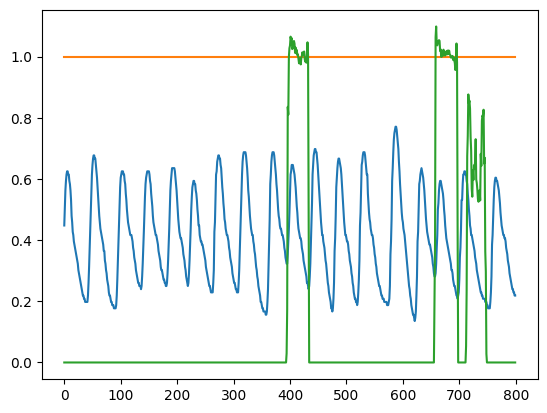

1.0


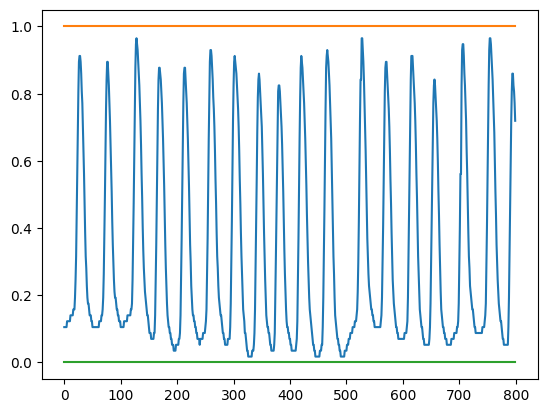

0.07597399


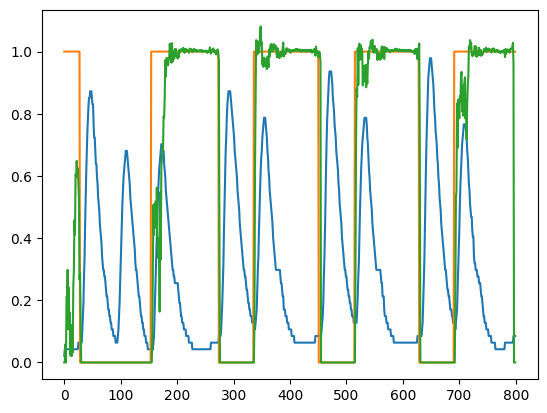

0.09354683


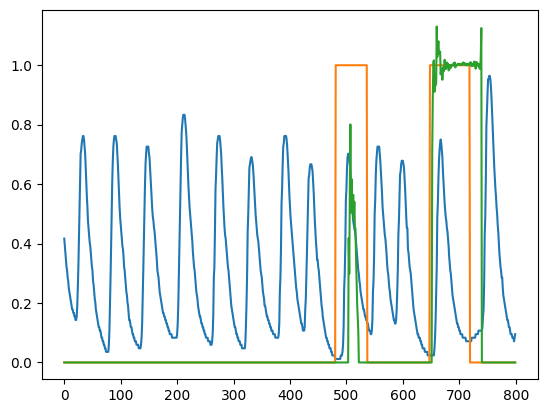

0.7420609


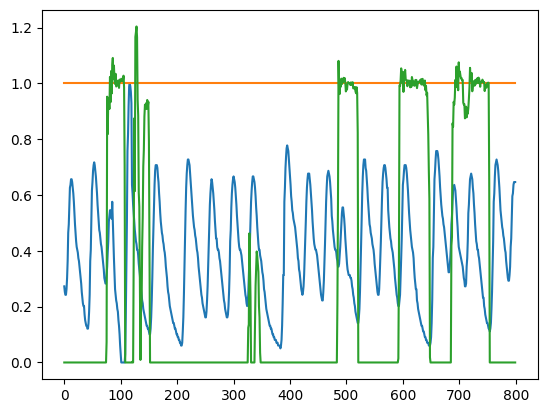

0.8759146


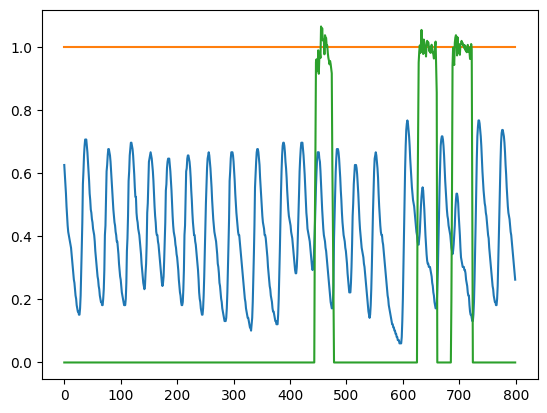

0.007164059


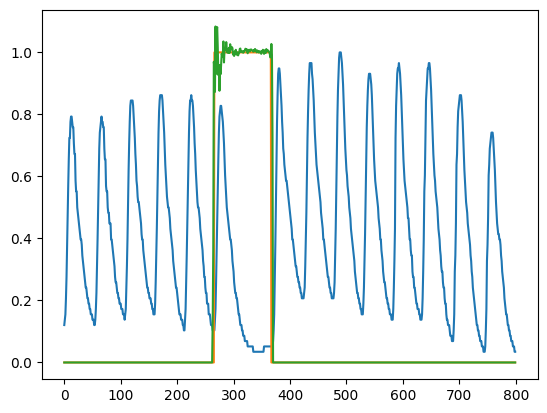

0.021295361


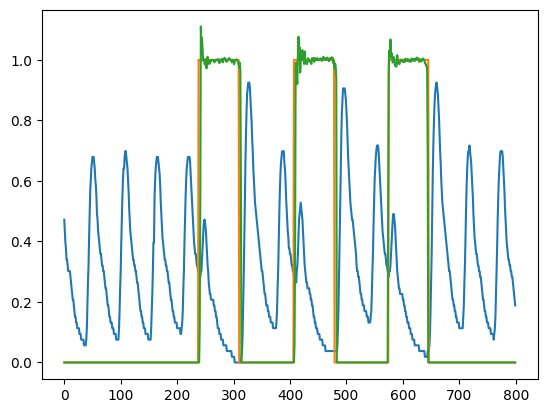

In [39]:
shower = performance()
test_data = PPGDataset('D:\ppg_project\Data\data_test',label_list = "AR")
shower.test(model,device,test_data,per_fnc = "series")
criterion = nn.L1Loss()
for i in range(len(test_data)):
    output = torch.stack([test_data[i][1]]).to(device)
    input = torch.stack([test_data[i][0]]).to(device)
    y_hat = model.forward(input)
    loss = criterion(y_hat,output)
    # if loss.cpu().detach().numpy()<0.3:
    print(loss.cpu().detach().numpy())
    plt.plot(input.cpu().detach().numpy().flatten()[0:1000])
    plt.plot(output.cpu().detach().numpy().flatten()[0:1000])
    plt.plot(y_hat.cpu().detach().numpy().flatten()[0:1000])
    plt.show()